## 目标与运行方法

下载完整 `.ipynb`，在 VibeIt Studio 文件浏览器中使用 **+ → Import from Files** 导入并打开。按从上到下的顺序运行代码单元；阅读模式中的图表是已保存的真实运行输出。重新运行会从内嵌数据计算结果。

本课适合具备 Python 基础的本科生。先阅读每一步的方法与图注，再修改参数。AI 练习为可选部分，不需要 AI 账号即可完成核心课程。数据写在 notebook metadata 中，不需要另下载数据文件。请保持 notebook 已保存到当前工作文件夹。

学习任务是理解本课的研究问题、执行透明的计算、校验结果，并说明结论的边界。

## 环境与参数

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from datetime import datetime
from IPython.display import display as _display
def display(value):
    if isinstance(value,pd.DataFrame):
        table=value.to_html(max_rows=12,escape=True)
        style="<style>.vibeit-readable-table{max-width:100%;overflow-x:auto}.vibeit-readable-table table{width:max-content;max-width:none;border-collapse:collapse}.vibeit-readable-table td,.vibeit-readable-table th{white-space:nowrap!important;word-break:normal!important;overflow-wrap:normal!important}</style>"
        return _display(HTML(style+'<div class="vibeit-readable-table">'+table+'</div>'))
    return _display(value)
RECIPE_ID='ec06-tail-risk'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### 读取内嵌快照

下面的加载函数按课程 ID 与 SHA-256 在当前文件夹定位本 notebook，解压后再次校验。文件改名不影响匹配。若找不到数据，确认当前工作目录与文件位置；不要用编造的数据替换它。metadata 随 `.ipynb` 保存及导出，复制代码到单独 `.py` 不会自动复制数据。

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'ecb': '7afd344000313ec2b4f6fb2548894e2a4817dc3687c14f8de47937ebf7bba0ad'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['ecb']


### 方法函数

本课所需函数的完整代码就在下面。它们只使用已列出的预装包与标准库，运行时不会导入任何 cookbook 辅助模块。先检查输入约束和返回值；如果修改算法，后面的校验也需要继续通过。

In [3]:
def empirical_tail_risk(losses,confidence=.95):
    """Inverse empirical-CDF VaR and fractional upper-tail expected shortfall."""
    losses=np.asarray(losses,dtype=float)
    if losses.ndim!=1 or len(losses)<2 or not np.isfinite(losses).all() or not 0<confidence<1:
        raise ValueError('Need finite losses and confidence strictly between zero and one')
    ordered=np.sort(losses)[::-1];mass=(1-confidence)*len(ordered);full=int(np.floor(mass));fraction=mass-full
    tail_sum=float(ordered[:full].sum())
    if fraction>0:tail_sum+=fraction*ordered[full]
    return dict(VaR=float(np.quantile(losses,confidence,method='inverted_cdf')),expected_shortfall=tail_sum/mass,tail_sample_mass=mass)

print("Method ready: empirical_tail_risk")


Method ready: empirical_tail_risk


In [4]:
def circular_block_resample(values,block_length=5,seed=42):
    """One circular block bootstrap draw; stationary resampling is assumed."""
    values=np.asarray(values,dtype=float)
    if values.ndim!=1 or len(values)<2 or not np.isfinite(values).all() or not isinstance(block_length,(int,np.integer)) or not 1<=block_length<=len(values):
        raise ValueError('Invalid sequence or block length')
    rng=np.random.default_rng(seed);count=int(np.ceil(len(values)/block_length))
    starts=rng.integers(0,len(values),count)
    indices=(starts[:,None]+np.arange(block_length)[None,:])%len(values)
    return values[indices.ravel()[:len(values)]]

print("Method ready: circular_block_resample")


Method ready: circular_block_resample


In [5]:
def iso_datetimes(values):
    """Parse source ISO dates with the standard library; keep tables as ISO strings."""
    return [datetime.fromisoformat(str(value)) for value in values]

print("Method ready: iso_datetimes")


Method ready: iso_datetimes


### 数据与模型边界

历史价格型货币例子假设每日再平衡，不含利息/套息、费用、成交成本和税，不确定未来表现或构成投资建议。来源：ECB，原始参考汇率可在 ECB 免费取得。倒数、收益和风险统计为课程派生计算，不是 ECB 统计。

## 分步分析

### 1. 声明假设损失序列

损失是倒数货币价格等权简单收益的相反数，负损失代表收益；价格篮子不含实际交易、利息/套息、费用或税。

Source: European Central Bank. The original reference rates are available free from the ECB. Course returns, inversions and risk estimates are derived calculations, not ECB statistics.
Quote: Foreign currency units per 1 EUR ; common complete dates: 1538 of 1538


,USD,GBP,JPY,CNY
date,,,,
2019-01-02,1.1397,0.90165,124.28,7.8165
2019-01-03,1.1348,0.90312,122.21,7.8019
2019-01-04,1.1403,0.89988,123.20,7.8280
2019-01-07,1.1445,0.89720,123.90,7.8421
2019-01-08,1.1440,0.89743,124.46,7.8405
2019-01-09,1.1455,0.89913,124.70,7.8226


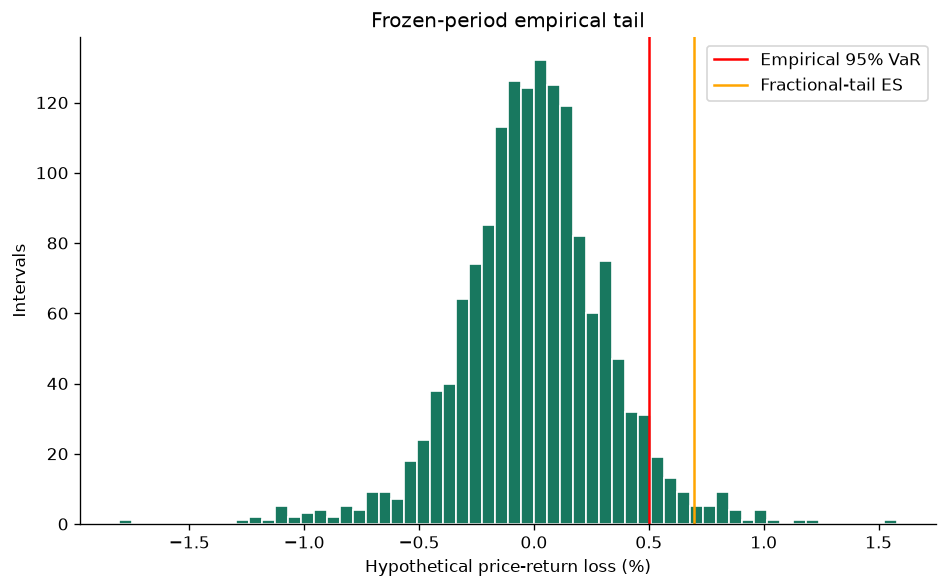

In [6]:
ecb=snapshot("ecb");rates=pd.DataFrame(ecb["rows"])
rates["date"]=rates["Date"].astype(str);rates=rates.set_index("date").sort_index()
currencies=ecb["currency_order"];original_dates=len(rates);rates=rates[currencies].dropna()
assert rates.index.is_unique and rates.index.is_monotonic_increasing and (rates>0).all().all()
prices=1/rates;returns=prices.pct_change(fill_method=None).iloc[1:]
print(ecb["source_notice"])
print("Quote:",ecb["quote"],"; common complete dates:",len(rates),"of",original_dates)
display(rates.head(6))
losses=-(returns.to_numpy()@np.full(4,.25));risk=empirical_tail_risk(losses,.95)
fig,ax=plt.subplots(figsize=(8,5));ax.hist(100*losses,bins=60,edgecolor="white")
ax.axvline(100*risk["VaR"],color="red",label="Empirical 95% VaR");ax.axvline(100*risk["expected_shortfall"],color="orange",label="Fractional-tail ES")
ax.set(xlabel="Hypothetical price-return loss (%)",ylabel="Intervals",title="Frozen-period empirical tail");ax.legend();plt.tight_layout();plt.show()


### 2. 声明有限样本约定

VaR 使用经验逆 CDF 次序统计量；ES 平均最差 (1−alpha)n 样本质量，包含必要的下一观测分数质量。插值分位数以上均值可能采用不同约定。

,confidence,VaR,expected_shortfall,tail_sample_mass
0,0.90,0.003717,0.005646,153.70
1,0.95,0.005020,0.006980,76.85
2,0.99,0.008298,0.010010,15.37


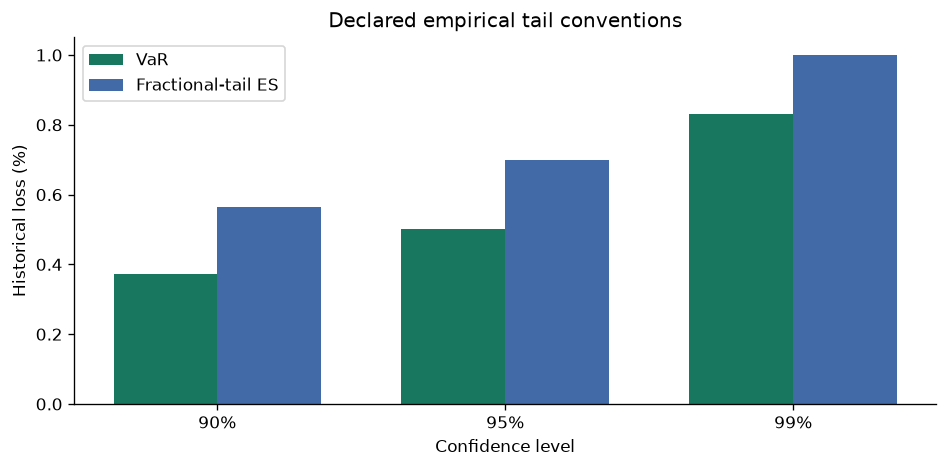

In [7]:
confidence=[.90,.95,.99]
risk_table=pd.DataFrame([{"confidence":level,**empirical_tail_risk(losses,level)} for level in confidence]);display(risk_table)
fig,ax=plt.subplots(figsize=(8,4));positions=np.arange(3)
ax.bar(positions-.18,100*risk_table.VaR,width=.36,label="VaR");ax.bar(positions+.18,100*risk_table.expected_shortfall,width=.36,label="Fractional-tail ES")
ax.set_xticks(positions,[f"{q:.0%}" for q in confidence]);ax.set(xlabel="Confidence level",ylabel="Historical loss (%)",title="Declared empirical tail conventions");ax.legend();plt.tight_layout();plt.show()


### 3. 检查条件循环分块变异

五观测循环块保留块内次序，假定平稳重采样；首尾连接为人工构造，不是真实相邻日期。区间描述条件历史变异，不保证明日损失。

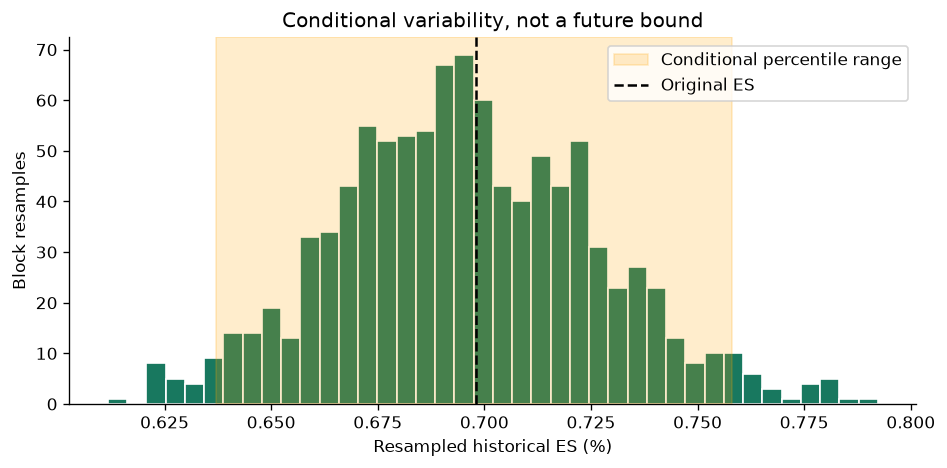

In [8]:
draws=[]
for seed in range(1000):
 sampled=circular_block_resample(losses,block_length=5,seed=seed);value=empirical_tail_risk(sampled,.95)
 draws.append([value["VaR"],value["expected_shortfall"]])
draws=np.asarray(draws);interval=np.quantile(draws[:,1],[.025,.975])
fig,ax=plt.subplots(figsize=(8,4));ax.hist(100*draws[:,1],bins=40,edgecolor="white")
ax.axvspan(*(100*interval),color="orange",alpha=.2,label="Conditional percentile range");ax.axvline(100*risk["expected_shortfall"],color="black",linestyle="--",label="Original ES")
ax.set(xlabel="Resampled historical ES (%)",ylabel="Block resamples",title="Conditional variability, not a future bound");ax.legend();plt.tight_layout();plt.show()


### 4. 检查手算分数尾部

[0,1,2,3]、alpha=.625 的尾质量为 1.5，ES=(3+0.5·2)/1.5。核对约定、ES≥VaR 及非法端点，再导出完整假设。

In [9]:
fixture=empirical_tail_risk(np.array([0,1,2,3]),.625)
assert np.isclose(fixture["expected_shortfall"],(3+.5*2)/1.5)
assert np.all(risk_table.expected_shortfall>=risk_table.VaR-1e-15)
try:empirical_tail_risk(losses,1)
except ValueError:print("Empty-tail confidence endpoint rejected")
else:raise AssertionError("Invalid confidence accepted")
OUTPUT_DIR.mkdir(parents=True,exist_ok=True);risk_table.to_csv(OUTPUT_DIR/"empirical-tail-risk.csv",index=False)
pd.DataFrame(draws,columns=["VaR","fractional_ES"]).to_csv(OUTPUT_DIR/"conditional-block-risk.csv",index=False)
pd.DataFrame({"date":returns.index,"hypothetical_loss":losses}).to_csv(OUTPUT_DIR/"hypothetical-loss-sequence.csv",index=False)
print("Hand-calculated tail check passed; conditional ES range:",interval)


Empty-tail confidence endpoint rejected
Hand-calculated tail check passed; conditional ES range: [0.00637013 0.00758114]


## 自主练习与参考答案

1. 为何声明分位和尾质量约定？
2. 循环块依赖哪些假设？

**参考解释。** 经验插值和逆 CDF 尾积分不同。循环块假定平稳且人工连接首尾，区间为条件性。

先保留当前 notebook 副本，再修改参数。把新图与原图一起比较，并记录改变了哪些输入、哪些计算和哪些结论。

## 可选的 AI 编程练习

在 VibeIt 的 Coding Agent 中打开当前 notebook，先让助手阅读相关单元。核心课程不依赖 AI 服务；服务可用性与账号设置以应用帮助中心为准。

**提示词 1**

> 仅用 NumPy、Pandas、Matplotlib 比较块长一、五、十并记录种子。

**提示词 2**

> 同包按确切经验约定导出 90%、95%、99% 风险。

**人工验收。** 手算通过、ES≥VaR、拒绝置信端点，不保证未来损失。

检查修改后的源代码，再手动运行受影响单元及后续校验。要求助手解释修改的目的、使用的包和数据来源，并用实际输出核对解释。

## 可选联网扩展

默认关闭下面的联网操作。它只显示数据库版本及快照来源，不会替换核心数据。若要重新获取数据，应另存一个实验版本并记录新的 URL、数据库版本、获取日期与 SHA-256；新版结果需要重新执行和核验。

In [10]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://data-api.ecb.europa.eu/service/data/EXR/D.USD.EUR.SP00.A?startPeriod=2024-01-01&endPeriod=2024-12-31&format=csvdata',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## 来源、快照与下一步

- [ECB SDMX euro reference exchange rates](https://data-api.ecb.europa.eu/service/data/EXR/D.USD+GBP+JPY+CNY.EUR.SP00.A?startPeriod=2019-01-01&endPeriod=2024-12-31&format=csvdata) — ECB copyright / free reuse with accurate source attribution; data obtained free from ECB; derived returns explicitly labelled; retrieved 2026-10-09. SHA-256 `5f39fc39f60606abafae26c00492d05388c7bdf29cce1922f173f99bd0273ce8`.
  Retain 2019-01-01 through 2024-12-31 and USD, GBP, JPY, CNY; preserve missing values and quotation direction.


**下一步。** 在保留本课的数据检查、参数记录和结果校验之后，将相同方法用于自己的公开或已获授权数据。记录研究设计与方法限制，不把示例结果当成新实验的验证。完整数据许可与生成说明见 cookbook 网页。